Bloque 1 - Montar Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Bloque 2 - Imporatmos la libreria tensorflow

In [2]:
import tensorflow as tf

BLoque 3 - Descarga de datos

In [3]:
import kagglehub # Importa la librería kagglehub para interactuar con Kaggle y descargar datasets.

path = kagglehub.dataset_download("muhammedjunayed/wavelet-transformed-eeg-data-for-alcohol-detection")

print("Path to dataset files:", path) # Imprime la ruta donde se han descargado los archivos del dataset.

Using Colab cache for faster access to the 'wavelet-transformed-eeg-data-for-alcohol-detection' dataset.
Path to dataset files: /kaggle/input/wavelet-transformed-eeg-data-for-alcohol-detection


Bloque 4 - Exploracion de archivos

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


path = Path(path)
img_as_jpg = list(path.rglob(r"*/*.jpg"))

# Counts the number of each categories in the dataset
file_count = list(map(lambda x: os.path.split(os.path.split(x)[0])[1],img_as_jpg))
Alc = file_count.count('Alc')
Con = file_count.count('Con')

In [5]:
Alc

468

In [6]:
Con

456

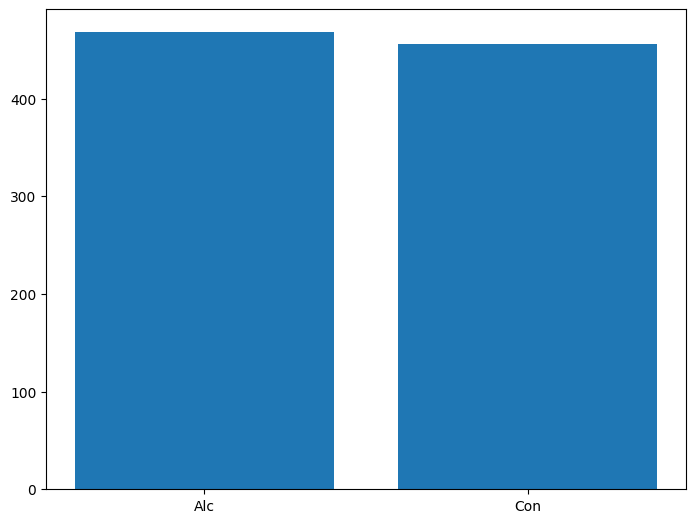

In [7]:
#VISUALIZACION DE DATA POR CLASES ALCOHOL O CONTROL
fig = plt.figure()
ax = fig.add_axes([1,1,1,1])
labels = ['Alc','Con']
count_train = [Alc, Con] # count_train should contain the count of each label
ax.bar(labels, count_train)
plt.show()

BLOQUE 5 - IMPLEMENTACION DEL MODELO MLP-Mixer

In [8]:
#MODELO MLP-Mixer (Multi-Layer Perceptron Mixer)
#BLOQUE 01
import tensorflow as tf
from tensorflow.keras import layers, models

# Clase utilitaria para acceder a claves de diccionario como atributos
class AttrDict(dict):
    __setattr__ = dict.__setitem__
    __getattr__ = dict.__getitem__

# Función de visualización
def plot_grid_ds(ds, model=None, size=(3, 3), figsize=(10, 10)):
    from copy import copy
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1 import ImageGrid

    n = size[0] * size[1]
    ds_ = copy(ds)

    fig = plt.figure(figsize=figsize)
    grid = ImageGrid(
        fig,
        111,
        nrows_ncols=size,
        axes_pad=0.3,
    )
    for X_batch, y_batch in ds_.unbatch().shuffle(n).batch(n).take(1):
        y_hat_batch = model.predict(X_batch).argmax(axis=-1) if model else y_batch
        for X, y, y_hat, ax in zip(X_batch, y_batch, y_hat_batch, grid):
            title = (
                f"{ds.class_names[y]} (true) - {ds.class_names[y_hat]} (pred)"
                if model
                else f"{ds.class_names[y]}"
            )
            ax.set_title(title)
            ax.axes.xaxis.set_visible(False)
            ax.axes.yaxis.set_visible(False)
            ax.imshow(X / 255, cmap="gray")
    return grid

# Métrica personalizada
class BalancedSparseCategoricalAccuracy(tf.keras.metrics.SparseCategoricalAccuracy):
    def __init__(self, name="balanced_sparse_categorical_accuracy", dtype=None):
        super().__init__(name, dtype=dtype)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_flat = y_true
        if y_true.shape.ndims == y_pred.shape.ndims:
            y_flat = tf.squeeze(y_flat, axis=[-1])
        y_true_int = tf.cast(y_flat, tf.int32)
        cls_counts = tf.math.bincount(y_true_int)
        cls_counts = tf.math.reciprocal_no_nan(tf.cast(cls_counts, self.dtype))
        weight = tf.gather(cls_counts, y_true_int)
        return super().update_state(y_true, y_pred, sample_weight=weight)

# --- IMPLEMENTACIÓN DEL MODELO MLP-Mixer ---
# Una arquitectura basada enteramente en MLPs, sin convoluciones ni auto-atención (ViT).

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]

        # CORRECCIÓN: Calcular dimensiones estáticas para evitar el error "no None dimensions"
        # MLP-Mixer requiere un número fijo de tokens para las capas Dense de Token-Mixing.
        if images.shape[1] is not None and images.shape[2] is not None:
            # Si la forma de entrada es conocida (ej: 224x224), calculamos el número exacto de parches.
            seq_len = (images.shape[1] // self.patch_size) * (images.shape[2] // self.patch_size)
            patches = tf.reshape(patches, [batch_size, seq_len, patch_dims])
        else:
            # Fallback dinámico (puede fallar si no se infiere la forma en graph mode)
            patches = tf.reshape(patches, [batch_size, -1, patch_dims])

        return patches

class MLPBlock(layers.Layer):
    def __init__(self, hidden_dim, activation=tf.nn.gelu):
        super(MLPBlock, self).__init__()
        self.hidden_dim = hidden_dim
        self.activation = activation

    def build(self, input_shape):
        # input_shape es (Batch, ..., InputDim)
        self.dense1 = layers.Dense(self.hidden_dim)
        # La segunda densa proyecta de vuelta a la dimensión original de entrada
        self.dense2 = layers.Dense(input_shape[-1])
        super(MLPBlock, self).build(input_shape)

    def call(self, x):
        y = self.dense1(x)
        y = self.activation(y)
        return self.dense2(y)

class MixerBlock(layers.Layer):
    def __init__(self, tokens_mlp_dim, channels_mlp_dim):
        super(MixerBlock, self).__init__()
        self.tokens_mlp_dim = tokens_mlp_dim
        self.channels_mlp_dim = channels_mlp_dim

    def build(self, input_shape):
        self.layer_norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm2 = layers.LayerNormalization(epsilon=1e-6)
        # Token-mixing MLP: Opera sobre la dimensión de tokens (secuencia)
        self.token_mixing = MLPBlock(self.tokens_mlp_dim)
        # Channel-mixing MLP: Opera sobre la dimensión de canales (embedding)
        self.channel_mixing = MLPBlock(self.channels_mlp_dim)
        super(MixerBlock, self).build(input_shape)

    def call(self, x):
        # Token mixing (Mezcla información espacial)
        y = self.layer_norm1(x)
        y = tf.transpose(y, [0, 2, 1])  # [Batch, Channel, Tokens]
        y = self.token_mixing(y)        # MLP se aplica a la última dimensión (Tokens)
        y = tf.transpose(y, [0, 2, 1])  # [Batch, Tokens, Channel]
        x = layers.Add()([x, y])        # Skip connection

        # Channel mixing (Mezcla información de canales/features)
        y = self.layer_norm2(x)
        y = self.channel_mixing(y)      # MLP se aplica a la última dimensión (Channel)
        x = layers.Add()([x, y])        # Skip connection
        return x

class MLPMixer(tf.keras.Model):
    def __init__(self, input_shape, n_classes, patch_size=16, embedding_dim=256, num_blocks=8, tokens_mlp_dim=128, channels_mlp_dim=1024, **kwargs):
        super(MLPMixer, self).__init__()
        self.input_tensor_shape = input_shape
        self.n_classes = n_classes
        self.patch_size = patch_size
        self.embedding_dim = embedding_dim
        self.num_blocks = num_blocks
        self.tokens_mlp_dim = tokens_mlp_dim
        self.channels_mlp_dim = channels_mlp_dim
        self._construct_model()

    def call(self, x):
        return self._model(x)

    def _construct_model(self):
        inputs = layers.Input(shape=self.input_tensor_shape)

        # 1. Patch Extraction and Linear Embedding
        patches = Patches(self.patch_size)(inputs)
        x = layers.Dense(self.embedding_dim)(patches) # Projection

        # 2. Mixer Blocks
        for _ in range(self.num_blocks):
            x = MixerBlock(self.tokens_mlp_dim, self.channels_mlp_dim)(x)

        # 3. Classification Head
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dropout(0.5)(x)
        outputs = layers.Dense(self.n_classes)(x)

        self._model = models.Model(inputs=inputs, outputs=outputs, name="MLPMixer_Internal")

# Alias de compatibilidad por si se usa el nombre anterior
DeiTClassifier = MLPMixer

In [12]:
#08
train = pd.concat([pd.Series(img_as_jpg,name="image").apply(str),pd.Series(file_count, name="type")],axis=1)
train = train.sample(frac=1).reset_index(drop=True)
print(np.shape(train))

(924, 2)


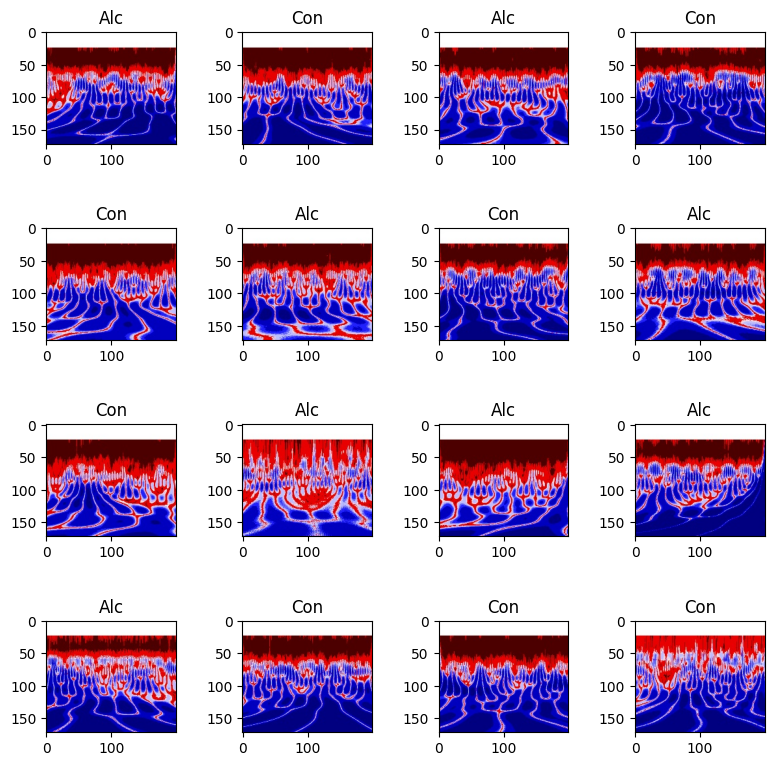

In [22]:
#09
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.tight_layout()
counter = 0
for ax in axes.reshape(-1):
    ax.imshow(plt.imread(train["image"][counter]))
    ax.set_title(train["type"][counter])
    plt.rcParams["axes.grid"] = False
    counter = counter+1

In [23]:
hparams = AttrDict(
    image_size=(224, 224, 3),  # Adjusted to be divisible by patch size
    n_classes=2,
    batch_size=32,
)

ds = tf.keras.preprocessing.image_dataset_from_directory("/content/drive/MyDrive/Papper_Titulo /EEG", image_size=hparams.image_size[:-1], batch_size=hparams.batch_size)
train_split = round(0.8 * ds.cardinality().numpy())
train_ds = ds.take(train_split); train_ds.class_names = ds.class_names
validation_ds = ds.skip(train_split); validation_ds.class_names = ds.class_names

Found 924 files belonging to 2 classes.


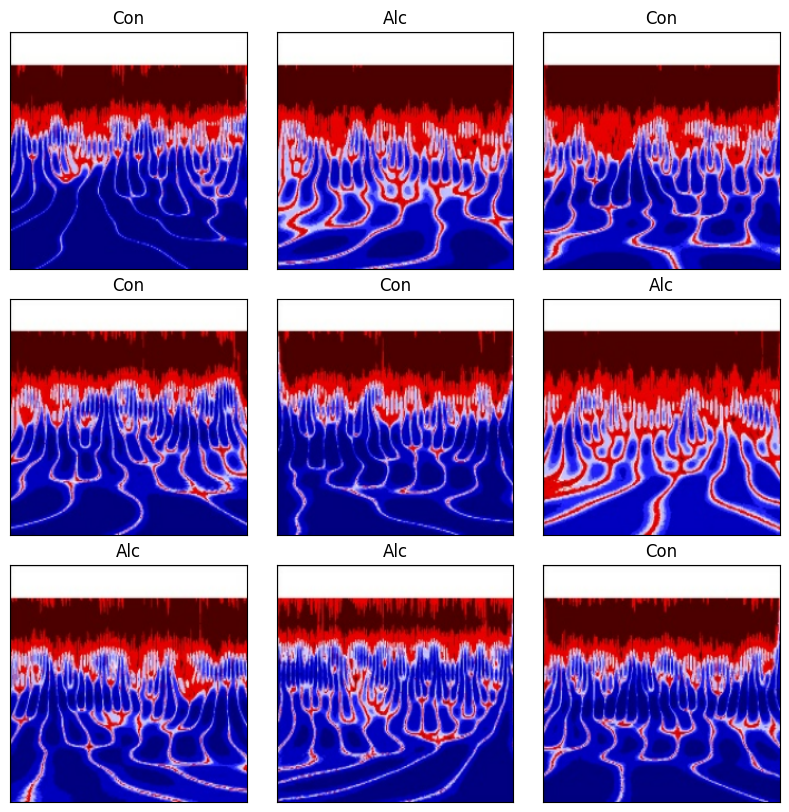

In [24]:
_ = plot_grid_ds(train_ds)


BLOQUE 5: RESULTADOS DEL MODELO MLP-Mixer

---



---



Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 314ms/step - accuracy: 0.5464 - balanced_sparse_categorical_accuracy: 0.5197 - loss: 0.7437 - val_accuracy: 0.5000 - val_balanced_sparse_categorical_accuracy: 0.4996 - val_loss: 0.6863
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 259ms/step - accuracy: 0.5252 - balanced_sparse_categorical_accuracy: 0.5373 - loss: 0.6956 - val_accuracy: 0.4734 - val_balanced_sparse_categorical_accuracy: 0.4950 - val_loss: 0.7000
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 264ms/step - accuracy: 0.5071 - balanced_sparse_categorical_accuracy: 0.5207 - loss: 0.7083 - val_accuracy: 0.5000 - val_balanced_sparse_categorical_accuracy: 0.5000 - val_loss: 0.7276
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step - accuracy: 0.5319 - balanced_sparse_categorical_accuracy: 0.5127 - loss: 0.7028 - val_accuracy: 0.4734 - val_balanced_sparse_categorical_accuracy: 0.5049 - val_loss: 0.7507
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 262ms/step - accuracy: 0.4909 - balanced_sparse_catego

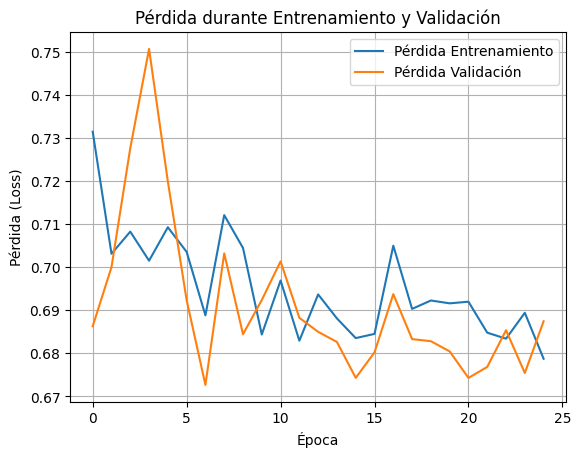

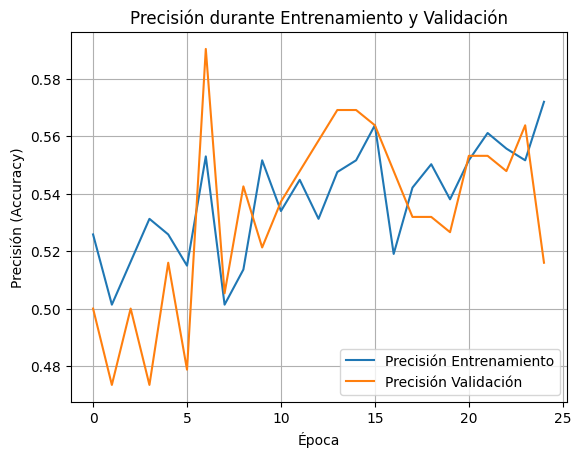

Precisión Final en Entrenamiento: 57.20%
Precisión Final en Validación: 51.60%
Tiempo total tomado: 160.28 segundos
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step


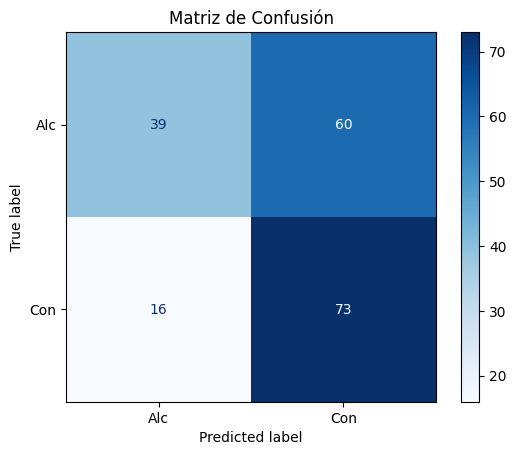


Precisión por clase (Precision): [0.70909091 0.54887218]

Sensibilidad por clase (Recall): [0.39393939 0.82022472]

Puntaje F1 por clase (F1-score): [0.50649351 0.65765766]

Precisión Global (Overall Accuracy): 59.57%

Precisión Macro (Macro Precision): 0.6289815447710185

Sensibilidad Macro (Macro Recall): 0.6070820565202588

F1-score Macro: 0.5820755820755821


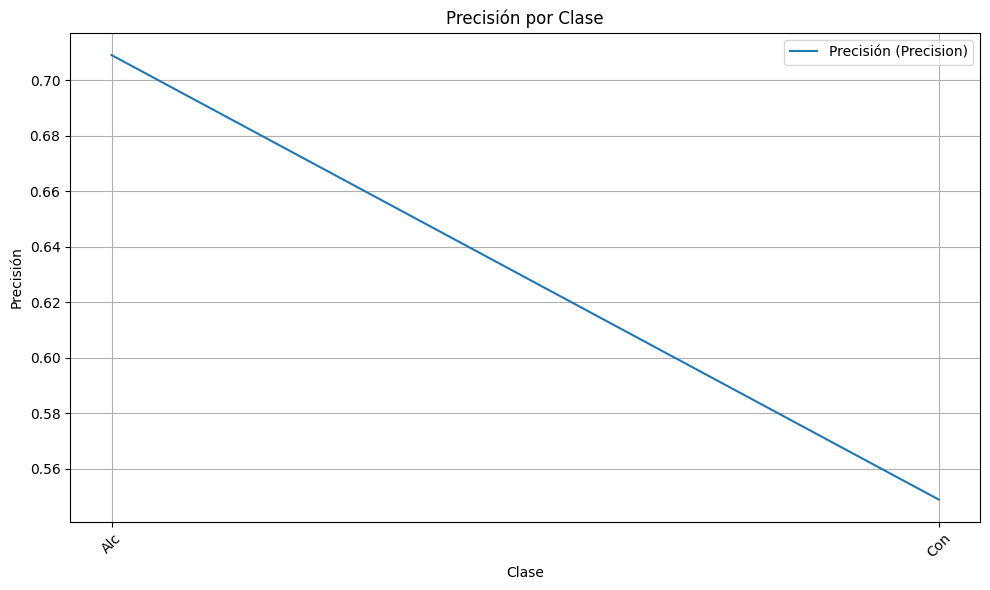

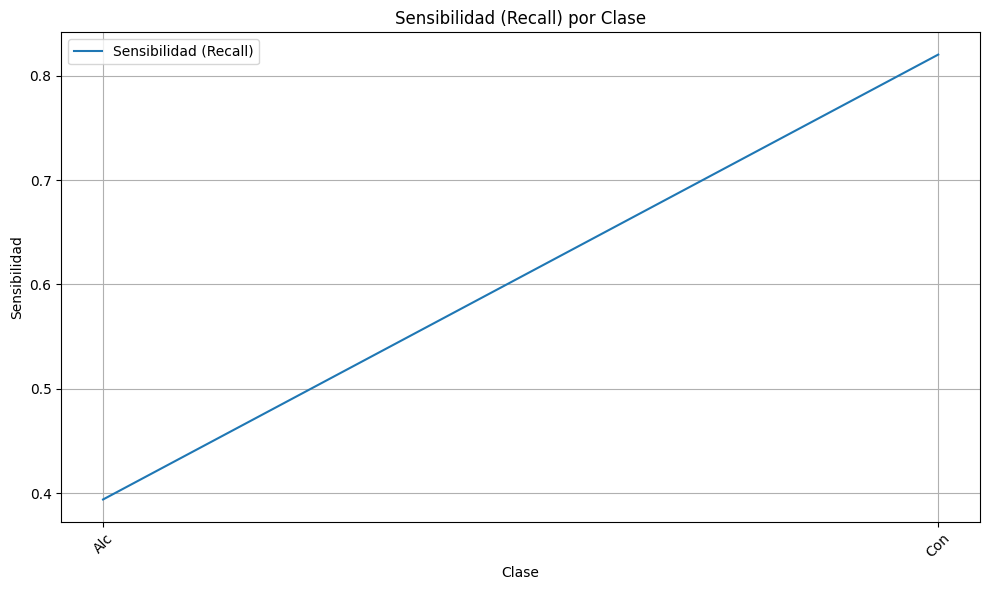

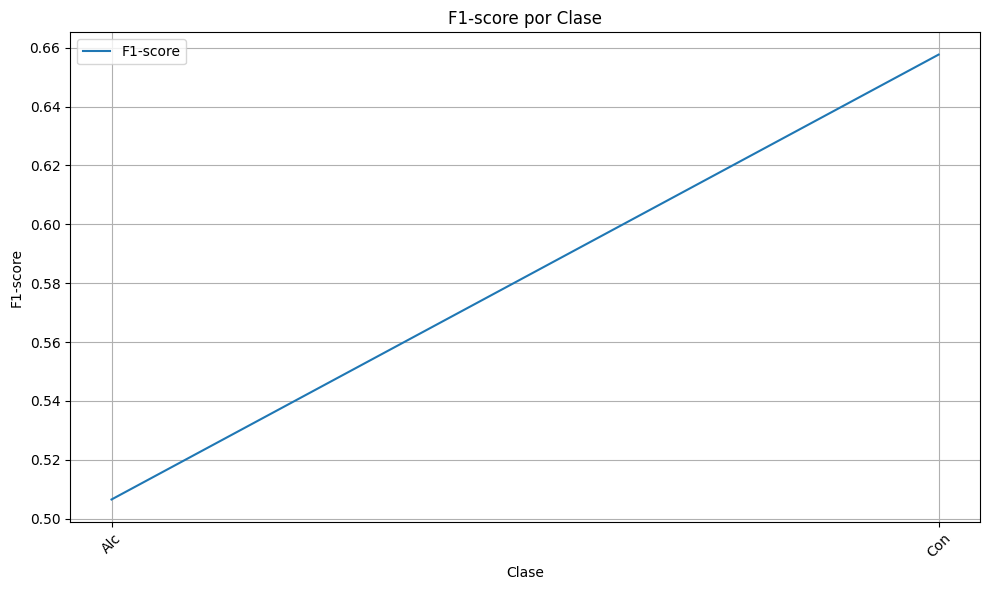

In [36]:
# Ejecutando entrenamiento con MLPMixer
import time
import tensorflow as tf
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- CORRECCIÓN: Reinstanciar el modelo para asegurar que se use la definición de clase actualizada ---
# Verificar si la estrategia de distribución (para GPU/TPU) existe, si no, crearla.
# Esto es útil para entrenar en múltiples GPUs si están disponibles.
if 'strategy' not in globals():
    strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    # Asumiendo que 'hparams' (hiperparámetros) está disponible desde celdas anteriores.
    # input_shape define el tamaño de las imágenes de entrada (224, 224, 3).
    input_shape = hparams['image_size']
    # n_classes define el número de categorías a predecir (2: Alcohol vs Control).
    n_classes = hparams['n_classes']

    # Reconstruir el modelo con la clase MLPMixer CORREGIDA.
    # Es vital recrearlo aquí para que tome los cambios si editaste la clase MLPMixer en celdas anteriores.
    model = MLPMixer(input_shape, n_classes)

    # Compilar el modelo: Paso crucial antes del entrenamiento.
    # Se define el optimizador (Adam) para ajustar los pesos del modelo.
    # Se define la función de pérdida (Crossentropy) para medir el error.
    # Se definen las métricas para evaluar el rendimiento.
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Learning rate bajo (0.0001) para una convergencia estable.
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), # 'from_logits=True' porque la salida final no tiene activación Softmax aplicada.
        metrics=["accuracy", BalancedSparseCategoricalAccuracy()] # Métrica personalizada para manejar desbalance de clases si existe.
    )
# --------------------------------------------------------------------------------

start = time.time() # Guardamos el tiempo actual para medir cuánto tarda el entrenamiento.

# Configurar un callback personalizado para registrar la pérdida y precisión durante el entrenamiento.
# Esto nos permite guardar el historial de métricas paso a paso para graficarlo después.
class TrainingHistory(tf.keras.callbacks.Callback):
  def __init__(self):
    # Inicializamos listas vacías para guardar los valores de cada época.
    self.losses = []
    self.val_losses = []
    self.accuracies = []
    self.val_accuracies = []

  def on_epoch_end(self, epoch, logs=None):
    # Al final de cada época, extraemos los valores del log y los guardamos.
    self.losses.append(logs.get('loss')) # Pérdida en entrenamiento
    self.val_losses.append(logs.get('val_loss')) # Pérdida en validación
    self.accuracies.append(logs.get('accuracy')) # Precisión en entrenamiento
    self.val_accuracies.append(logs.get('val_accuracy')) # Precisión en validación

# Instanciar el objeto historial
history = TrainingHistory()

# Iniciar el entrenamiento del modelo.
# Se usan los datos de 'train_ds' para ajustar el modelo.
# Se usa 'validation_ds' para evaluar el modelo en datos no vistos al final de cada época.
# 'epochs=25' indica que el modelo verá todo el dataset 25 veces.
model.fit(train_ds, epochs=25, validation_data=validation_ds, callbacks=[history])

# --- VISUALIZACIÓN DE RESULTADOS ---

# 1. Graficar las curvas de PÉRDIDA (Loss)
# La pérdida debería disminuir con el tiempo. Si la validación sube mientras entrenamiento baja, hay sobreajuste (overfitting).
plt.plot(history.losses, label='Pérdida Entrenamiento')
plt.plot(history.val_losses, label='Pérdida Validación')
plt.title('Pérdida durante Entrenamiento y Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida (Loss)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# 2. Graficar las curvas de PRECISIÓN (Accuracy)
# La precisión debería aumentar. Buscamos que ambas líneas (entrenamiento y validación) sean altas y cercanas.
plt.plot(history.accuracies, label='Precisión Entrenamiento')
plt.plot(history.val_accuracies, label='Precisión Validación')
plt.title('Precisión durante Entrenamiento y Validación')
plt.xlabel('Época')
plt.ylabel('Precisión (Accuracy)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Imprimir la precisión final alcanzada en la última época
final_accuracy = history.accuracies[-1]
final_val_accuracy = history.val_accuracies[-1]
print(f"Precisión Final en Entrenamiento: {final_accuracy * 100:.2f}%")
print(f"Precisión Final en Validación: {final_val_accuracy * 100:.2f}%")

end = time.time()
print(f"Tiempo total tomado: {end - start:.2f} segundos")

## --- Matriz de Confusión y Cálculo de Métricas ---

# Evaluación detallada usando el conjunto de validación (validation_ds).

# Obtener todas las imágenes y sus etiquetas verdaderas del dataset de validación.
# Iteramos sobre el dataset para acumular los datos en listas.
X_val, y_true = [], []
for images, labels in validation_ds:
    X_val.extend(images.numpy())
    y_true.extend(labels.numpy())
X_val = np.array(X_val) # Convertir a array de numpy
y_true = np.array(y_true) # Convertir a array de numpy

# Realizar predicciones con el modelo entrenado.
# model.predict devuelve probabilidades (logits).
# argmax(axis=1) selecciona el índice de la clase con mayor probabilidad (0 o 1).
y_pred = model.predict(X_val).argmax(axis=1)

# Función auxiliar para graficar la matriz de confusión de forma estética.
def plot_confusion_matrix(y_true, y_pred, class_names):
    # Calcular la matriz de confusión comparando etiquetas reales vs predichas.
    cm = confusion_matrix(y_true, y_pred)
    # Visualizar la matriz usando etiquetas de clase.
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues") # Mapa de color azul
    plt.title('Matriz de Confusión')
    plt.show()

# Graficar la matriz de confusión.
# Muestra cuántos ejemplos de cada clase fueron clasificados correcta o incorrectamente.
plot_confusion_matrix(y_true, y_pred, class_names=validation_ds.class_names)

# Calcular métricas de clasificación detalladas por clase.
# Precisión (Precision): De los que predijo positivos, ¿cuántos eran realmente positivos?
class_wise_precision = precision_score(y_true, y_pred, average=None)
# Sensibilidad (Recall): De los que eran realmente positivos, ¿cuántos detectó el modelo?
class_wise_recall = recall_score(y_true, y_pred, average=None)
# F1-score: Media armónica entre precisión y recall. Buen balance.
class_wise_f1 = f1_score(y_true, y_pred, average=None)

print("\nPrecisión por clase (Precision):", class_wise_precision)
print("\nSensibilidad por clase (Recall):", class_wise_recall)
print("\nPuntaje F1 por clase (F1-score):", class_wise_f1)

# Calcular puntajes generales promediados (Macro average).
# Accuracy Global: Porcentaje total de aciertos.
accuracy = np.mean(y_true == y_pred)
macro_precision = precision_score(y_true, y_pred, average='macro')
macro_recall = recall_score(y_true, y_pred, average='macro')
macro_f1 = f1_score(y_true, y_pred, average='macro')

# Imprimir métricas globales.
print(f"\nPrecisión Global (Overall Accuracy): {accuracy * 100:.2f}%")
print("\nPrecisión Macro (Macro Precision):", macro_precision)
print("\nSensibilidad Macro (Macro Recall):", macro_recall)
print("\nF1-score Macro:", macro_f1)

# Graficar comparativa de métricas por clase.
plt.figure(figsize=(10, 6))
plt.plot(class_wise_precision, label='Precisión (Precision)')
plt.xticks(range(len(class_wise_precision)), validation_ds.class_names, rotation=45)
plt.xlabel('Clase')
plt.ylabel('Precisión')
plt.title('Precisión por Clase')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(class_wise_recall, label='Sensibilidad (Recall)')
plt.xticks(range(len(class_wise_recall)), validation_ds.class_names, rotation=45)
plt.xlabel('Clase')
plt.ylabel('Sensibilidad')
plt.title('Sensibilidad (Recall) por Clase')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(class_wise_f1, label='F1-score')
plt.xticks(range(len(class_wise_f1)), validation_ds.class_names, rotation=45)
plt.xlabel('Clase')
plt.ylabel('F1-score')
plt.title('F1-score por Clase')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


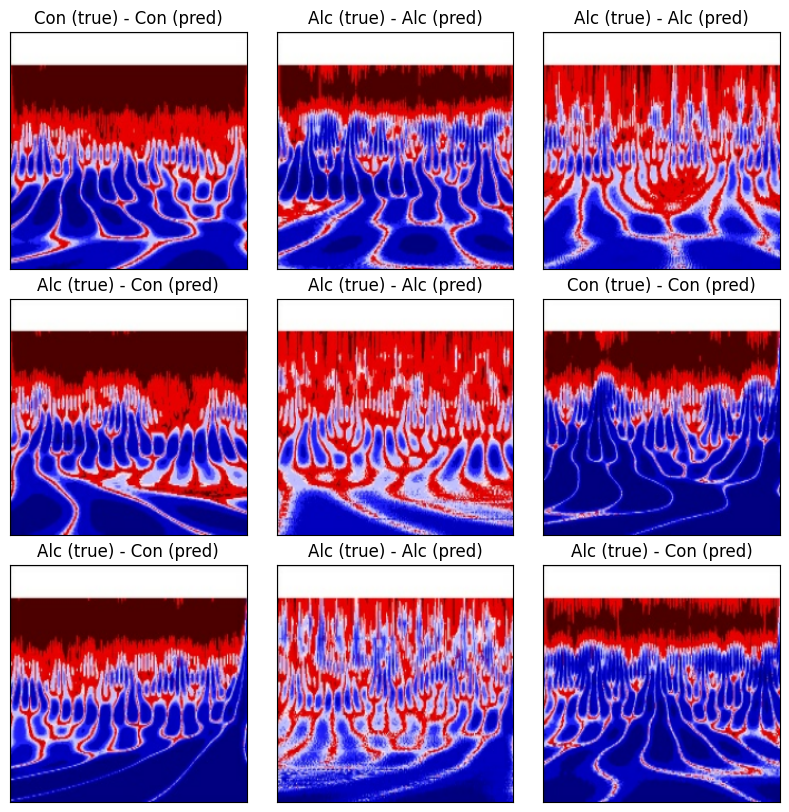

In [37]:
_ = plot_grid_ds(validation_ds,  model=model)

In [38]:
print("\nMacro F1-score:", macro_f1)



Macro F1-score: 0.5820755820755821


In [39]:
import pandas as pd

# === Datos del modelo (ajusta el nombre si quieres) ===
MODEL_NAME = "MLPMixer"
EPOCHS = 25
BATCH_SIZE = hparams.batch_size

# Obtener LR y optimizador desde el propio modelo
learning_rate = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
optimizer_name = type(model.optimizer).__name__

# Crear DataFrame con una fila de resultados
df_resultados = pd.DataFrame([{
    "Model": MODEL_NAME,
    "Accuracy": round(accuracy, 4),
    "Precision": round(macro_precision, 4),
    "Recall": round(macro_recall, 4),
    "F1-Score": round(macro_f1, 4),
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,

}])

# Mostrar tabla bonita en el notebook
df_resultados

,Model,Accuracy,Precision,Recall,F1-Score,batch_size,epochs
0,MLPMixer,0.5957,0.629,0.6071,0.5821,32,25


In [40]:
# Parche para corregir el conflicto de 'AttrDict' con la inspección de variables de Colab
# Esto evita el KeyError: 'shape' al cambiarlo por el AttributeError esperado
try:
    if 'AttrDict' in globals():
        def getattr_patch(self, key):
            try:
                return self[key]
            except KeyError:
                raise AttributeError(f"'AttrDict' object has no attribute '{key}'")
        AttrDict.__getattr__ = getattr_patch
except Exception:
    pass

# Definir la ruta donde se guardará el modelo
# Se utiliza la extensión .keras que es el formato recomendado actualmente
save_path = '/content/drive/MyDrive/Papper_Titulo /06_MLPMixer_EEG_Alcohol_Detection.keras'

# Guardar el modelo
model.save(save_path)

print(f"Modelo guardado exitosamente en: {save_path}")

Modelo guardado exitosamente en: /content/drive/MyDrive/Papper_Titulo /06_MLPMixer_EEG_Alcohol_Detection.keras


In [41]:
# Tabla por clase
df_por_clase = pd.DataFrame({
    "Class": validation_ds.class_names,
    "Precision": class_wise_precision,
    "Recall": class_wise_recall,
    "F1-Score": class_wise_f1,
})

df_por_clase

,Class,Precision,Recall,F1-Score
0,Alc,0.709091,0.393939,0.506494
1,Con,0.548872,0.820225,0.657658
